# A map of one month

The first thing anybody wants from a dataset is to look at it. On a HEALPix
store that takes one more step than on a lon/lat grid, because the data has
no lon/lat axes to hand `pcolormesh` and no two-dimensional shape at all.
A field is a flat vector over cells, and the geometry lives in the cell
index rather than in the array shape.

This example turns that vector into a picture, and shows the one mistake
everybody makes on the way.

*The figure is saved with this notebook. Run the cells in order, from the top, to compute it again. The same example on the web: [A map of one month](https://waterpark.dkrz.de/docs/examples/01_first_map/).*

## Opening the store

Nothing here is HEALPix-specific. It is a public Zarr store on S3, so an
anonymous client and an endpoint URL are the whole of the access story.

`chunks=None` gives plain lazy Zarr-backed arrays that slice in the size
of the selection, rather than dask arrays whose chunk grid is built
eagerly from the global shape. At these levels either would work. At the
regional levels it is the only thing that works, so it is the habit worth
having.

In [ ]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from healpix_geo import nested

URL = "s3://reanalysis/healpix/era5/P1M/level_7.zarr"
S3 = {"anon": True, "endpoint_url": "https://s3.waterpark.dkrz.de"}

ds = xr.open_zarr(URL, storage_options=S3, chunks=None)
print(ds)

## The shape is the surprise

The field has a `time` axis and a `cell` axis, and that is all. There is
no `lat`, no `lon`, and no second horizontal dimension to unroll into.

The level and the cell count determine each other exactly, through
`npix = 12 * 4**level`, so the store only has to record one of them. It
records both, in the CF grid mapping attributes, along with the ordering
scheme.

In [ ]:
level = ds.attrs["healpix_level"]
assert ds.attrs["healpix_order"] == "nested", "everything below assumes nested"

field = ds["tas"].sel(time="2021-07").squeeze()

print(f"level {level}, nside {2**level}, {field.sizes['cell']} cells")
print(f"one monthly map is {field.nbytes / 1e6:.1f} MB")

## Cells to pixels

To draw it, sample the map onto a raster: walk over the lon/lat points
you want to colour, ask HEALPix which cell each one falls into, and read
that cell's value. The lookup is arithmetic rather than a search, so a
raster of a million points costs nothing.

> **Warning: The nested/ring trap**
>
> HEALPix has two ways of numbering cells, *ring* and *nested*, and they
> are different permutations of the same map. Waterpark stores are
> nested throughout, and `healpix_geo.nested` is the matching namespace.
> Read a nested store with a ring indexer and nothing raises: you get a
> plausible looking map with the data shuffled into the wrong places.
> If a field looks like noise where it should look like a planet, this
> is why, and the assertion above is cheap insurance.

In [ ]:
lon = np.linspace(-180, 180, 1440)
lat = np.linspace(90, -90, 720)
mesh_lon, mesh_lat = np.meshgrid(lon, lat)

cells = nested.lonlat_to_healpix(mesh_lon.ravel(), mesh_lat.ravel(), level)
raster = field.values[cells.astype("int64")].reshape(mesh_lat.shape)

That is the whole of it. Five lines, no interpolation weights, and no
remapping step.

## The plot

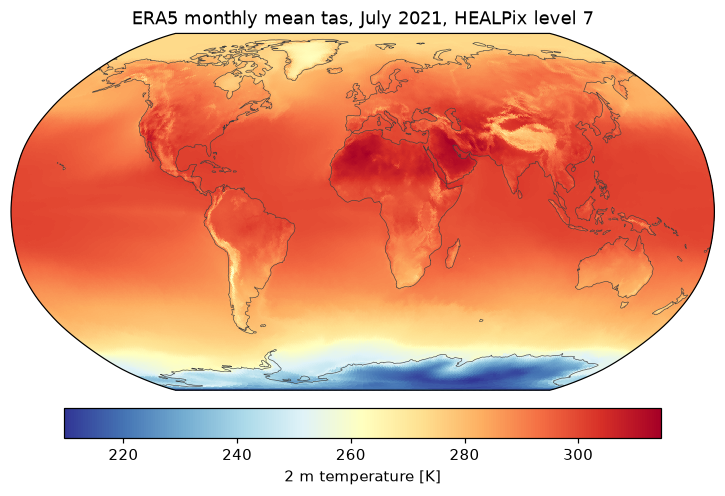

In [ ]:
fig, ax = plt.subplots(
    figsize=(10, 5.2), subplot_kw={"projection": ccrs.Robinson()}
)
ax.coastlines(linewidth=0.4, color="0.25")
ax.set_global()

mesh = ax.pcolormesh(
    lon, lat, raster, cmap="RdYlBu_r", shading="auto",
    transform=ccrs.PlateCarree(),
)
fig.colorbar(
    mesh, ax=ax, orientation="horizontal", pad=0.04, shrink=0.7,
    label="2 m temperature [K]",
)
ax.set_title("ERA5 monthly mean tas, July 2021, HEALPix level 7")

fig.savefig("01_first_map.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

## Nearest neighbour, on purpose

The raster is finer than the level 7 grid, so each cell is drawn with its
true boundary rather than smoothed across its neighbours. At this level
you have to look closely to see it; at level 4 the diamonds are obvious,
and they change orientation between the equatorial belt and the polar
caps.

Smoothing them away is a choice you should have to make on purpose, and
`healpix_geo.nested.bilinear_interpolation` gives you the weights when you
want it. The honest first look is the one above: it shows the resolution
you actually have rather than the resolution your screen has.

## Picking a level

This store is a pyramid. The same field is written at every level, and
changing one number in the URL changes how much you download:

| level | cells | one monthly field |
| ----- | ----- | ----------------- |
| 4     | 3 072 | 25 KB             |
| 5     | 12 288 | 98 KB            |
| 7     | 196 608 | 1.6 MB          |
| 8     | 786 432 | 6.3 MB          |

Level 7 is used here because the figure is a map and detail is the point.
The examples that read hundreds of time steps use level 4 instead, and
say so. Matching the level to the question is the single biggest lever
you have over how long an analysis takes.